<a href="https://colab.research.google.com/github/12Shreya8/semiconductor-yield-prediction-ml/blob/main/capstone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Capstone Project 2  
## Semiconductor Manufacturing Process – Pass/Fail Prediction


## 1. Project Objective

The objective of this project is to build a supervised machine learning model to predict the Pass/Fail yield of a semiconductor manufacturing process using sensor data.


## 2. Data Import and Library Setup

This section imports all the required libraries for data manipulation, visualization, preprocessing, and machine learning model development.


In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import joblib


## 2. Data Import

The dataset is loaded into the notebook using pandas. The shape of the dataset is examined to understand the number of observations and features.


In [40]:
df = pd.read_csv("https://raw.githubusercontent.com/12Shreya8/semiconductor-yield-prediction-ml/main/signal-data.csv")
df.shape


(1567, 592)

## 2. Data Understanding

This section explores the structure of the dataset, including feature types, target variable, and basic statistics.


In [41]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


**Observation:**  
The dataset consists of time-stamped sensor measurements along with a binary Pass/Fail target variable. The large number of sensor features highlights the high-dimensional nature of the data.


The sensor columns are renamed to improve readability and make further analysis easier.


In [42]:
total_columns = df.shape[1]

sensor_columns = (["Time"] +
                  [f"Sensor_{i}" for i in range(1, total_columns-1)] +
                  ["Pass/Fail"])

df.columns = sensor_columns


This cell displays the dataset after renaming columns, allowing a visual inspection of sensor values and the target variable.


In [43]:
df

,Time,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2008-10-16 15:13:00,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,2008-10-16 20:49:00,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2008-10-17 05:26:00,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2008-10-17 06:01:00,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1


The Time column is converted to a datetime format to ensure correct data type handling. Data types of all features are checked to confirm consistency.


In [44]:
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


In [45]:
df.dtypes

,0
Time,datetime64[ns]
Sensor_1,float64
Sensor_2,float64
Sensor_3,float64
Sensor_4,float64
...,...
Sensor_587,float64
Sensor_588,float64
Sensor_589,float64
Sensor_590,float64


This step identifies missing values across all sensor features to assess the extent of data incompleteness.


In [46]:
df.isna().sum()


,0
Time,0
Sensor_1,6
Sensor_2,7
Sensor_3,14
Sensor_4,14
...,...
Sensor_587,1
Sensor_588,1
Sensor_589,1
Sensor_590,1


### Missing Value Treatment

Missing values in numerical sensor features are handled using median imputation to reduce the influence of extreme values.


In [47]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('Pass/Fail')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())





This step verifies that all missing values in numerical sensor features have been successfully handled.


In [48]:
df[numeric_cols].isna().sum()


,0
Sensor_1,0
Sensor_2,0
Sensor_3,0
Sensor_4,0
Sensor_5,0
...,...
Sensor_586,0
Sensor_587,0
Sensor_588,0
Sensor_589,0


## Target Variable Distribution

The distribution of the Pass/Fail target variable is examined to identify potential class imbalance.


In [49]:
df['Pass/Fail'].value_counts()


,count
Pass/Fail,
-1,1463
1,104


**Observation:**  
The dataset is highly imbalanced, with significantly fewer failure cases compared to pass cases. This imbalance must be addressed during model training.


Descriptive statistics are computed to summarize the central tendency and spread of sensor measurements.


In [50]:
df.describe().round(2)

,Time,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6,Sensor_7,Sensor_8,Sensor_9,...,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590,Pass/Fail
count,1567,1567.00,1567.00,1567.00,1567.00,1567.00,1567.0,1567.00,1567.00,1567.00,...,1567.00,1567.00,1567.00,1567.0,1567.00,1567.00,1567.00,1567.00,1567.00,1567.00
mean,2008-07-30 21:44:12.712188928,3014.44,2495.87,2200.55,1395.38,4.17,100.0,101.12,0.12,1.46,...,82.40,0.50,0.02,0.0,3.07,0.02,0.02,0.01,99.65,-0.87
min,2008-01-08 02:02:00,2743.24,2158.75,2060.66,0.00,0.68,100.0,82.13,0.00,1.19,...,0.00,0.48,0.01,0.0,1.20,-0.02,0.00,0.00,0.00,-1.00
25%,2008-07-09 15:32:00,2966.66,2452.89,2181.10,1083.89,1.02,100.0,97.94,0.12,1.41,...,72.29,0.50,0.01,0.0,2.31,0.01,0.01,0.00,44.37,-1.00
50%,2008-08-23 13:02:00,3011.49,2499.40,2201.07,1285.21,1.32,100.0,101.51,0.12,1.46,...,72.29,0.50,0.01,0.0,2.76,0.02,0.01,0.00,71.90,-1.00
75%,2008-09-22 11:16:30,3056.54,2538.74,2218.06,1590.17,1.52,100.0,104.53,0.12,1.52,...,72.29,0.50,0.02,0.0,3.29,0.03,0.02,0.01,114.75,-1.00
max,2008-12-10 18:47:00,3356.35,2846.44,2315.27,3715.04,1114.54,100.0,129.25,0.13,1.66,...,737.30,0.51,0.48,0.1,99.30,0.10,0.08,0.03,737.30,1.00
std,NaN,73.48,80.23,29.38,439.84,56.10,0.0,6.21,0.01,0.07,...,56.35,0.00,0.02,0.0,3.58,0.01,0.01,0.00,93.86,0.50


In [51]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Pass/Fail')

## Outlier Detection and Treatment

Outliers are detected using the Interquartile Range (IQR) method and capped to reduce the influence of extreme values.


In [52]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_capped = df.copy()

for col in numeric_cols:
    df_capped[col] = np.where(
        df[col] < lower_bound[col], lower_bound[col],
        np.where(df[col] > upper_bound[col], upper_bound[col], df[col])
    )


The following boxplot visualizes the distribution of selected sensor features before outlier treatment.


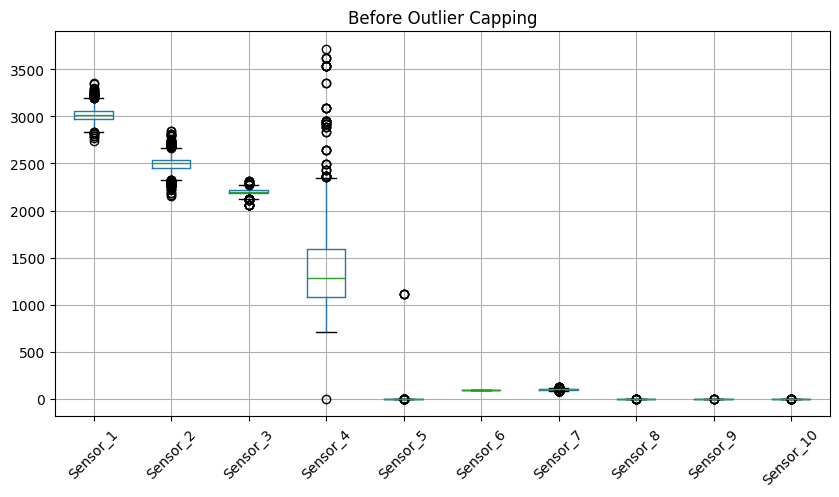

In [53]:
sample_cols = numeric_cols[:10]
plt.figure(figsize=(10, 5))
df[sample_cols].boxplot()
plt.title("Before Outlier Capping")
plt.xticks(rotation=45)
plt.show()

**Observation:**  
Several features exhibit extreme values outside the typical range, confirming the presence of outliers in the dataset.


The following boxplot shows the distribution of selected sensor features after applying outlier capping.


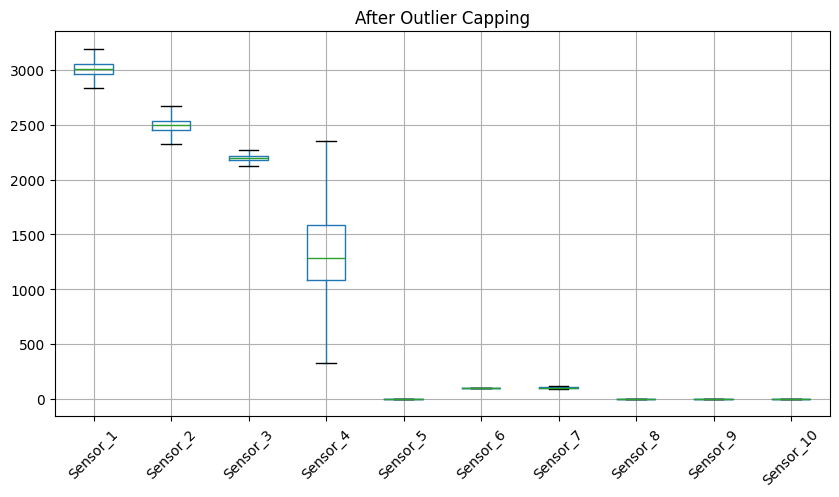

In [54]:
plt.figure(figsize=(10, 5))
df_capped[sample_cols].boxplot()
plt.title("After Outlier Capping")
plt.xticks(rotation=45)
plt.show()

**Observation:**  
After outlier capping, extreme values are reduced while preserving the overall distribution of the data.


A side-by-side comparison is performed to visually assess the impact of outlier capping on sensor feature distributions.

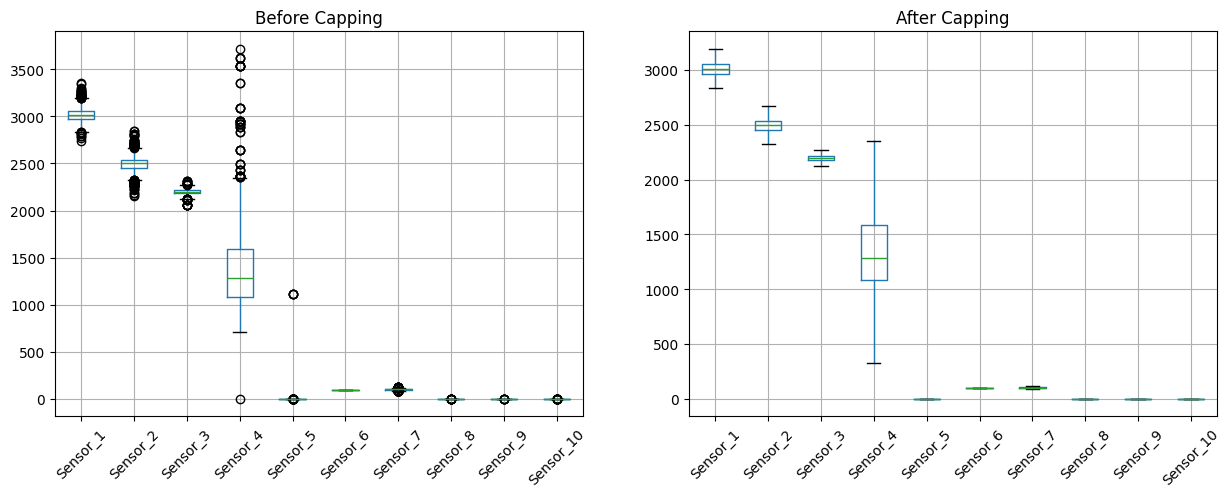

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df[sample_cols].boxplot(ax=axes[0])
axes[0].set_title("Before Capping")
axes[0].tick_params(axis='x', rotation=45)

df_capped[sample_cols].boxplot(ax=axes[1])
axes[1].set_title("After Capping")
axes[1].tick_params(axis='x', rotation=45)

plt.show()


## Feature and Target Separation

Predictor variables and the target variable are separated to prepare the dataset for model training.


In [56]:
X = df_capped.drop(['Time', 'Pass/Fail'], axis=1)
y = df['Pass/Fail']


The distribution of the target variable is rechecked before applying class imbalance handling techniques.


In [57]:
y.value_counts()

,count
Pass/Fail,
-1,1463
1,104


## Handling Class Imbalance Using SMOTE

SMOTE is applied to balance the target classes by synthetically generating minority class samples.


In [58]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

y_resampled.value_counts()


,count
Pass/Fail,
-1,1463
1,1463


**Observation:**  
After applying SMOTE, the dataset becomes balanced, enabling fair model training without bias toward the majority class.


## Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.25,
    random_state=42,
    stratify=y_resampled
)


## Feature Scaling

Standardization is applied to ensure all features contribute equally during model training.

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Training: Logistic Regression

A Logistic Regression model is trained as a baseline classifier and evaluated using accuracy and classification metrics.


In [61]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9289617486338798
              precision    recall  f1-score   support

          -1       1.00      0.86      0.92       366
           1       0.88      1.00      0.93       366

    accuracy                           0.93       732
   macro avg       0.94      0.93      0.93       732
weighted avg       0.94      0.93      0.93       732



**Observation:**  
The Logistic Regression model achieves strong overall performance, indicating that the preprocessed features are informative for classification.


## Model Training and Hyperparameter Tuning: Random Forest

A Random Forest classifier is trained using GridSearchCV to identify optimal hyperparameters. Cross-validation is applied to improve generalization performance.


In [62]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

cv = StratifiedKFold(n_splits=5)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9890710382513661
              precision    recall  f1-score   support

          -1       0.98      1.00      0.99       366
           1       1.00      0.98      0.99       366

    accuracy                           0.99       732
   macro avg       0.99      0.99      0.99       732
weighted avg       0.99      0.99      0.99       732



**Observation:**  
The Random Forest model achieves very high accuracy and balanced precision-recall scores, indicating strong performance on both classes.


## Model Training and Hyperparameter Tuning: Support Vector Machine (SVM)

An SVM classifier is trained with hyperparameter tuning using GridSearchCV to capture complex decision boundaries in the data.


In [63]:
svc = SVC()

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svc = GridSearchCV(
    svc,
    param_grid_svc,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_svc.fit(X_train_scaled, y_train)

best_svc = grid_svc.best_estimator_

y_pred_svc = best_svc.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))


SVM Accuracy: 0.9986338797814208
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       366
           1       1.00      1.00      1.00       366

    accuracy                           1.00       732
   macro avg       1.00      1.00      1.00       732
weighted avg       1.00      1.00      1.00       732



**Observation:**  
The SVM model achieves the highest accuracy among all tested models, demonstrating excellent classification performance.


## Model Comparison

The performance of all trained models is compared using accuracy to identify the best-performing classifier.


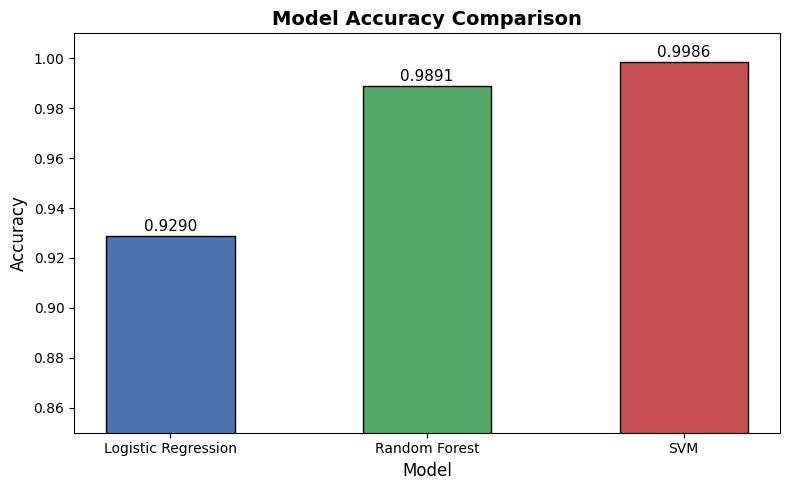

In [64]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc)
    ]
})

results


# Model Comparison Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results["Model"], results["Accuracy"], color=["#4C72B0", "#55A868", "#C44E52"], edgecolor="black", width=0.5)
plt.ylim(0.85, 1.01)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
for bar, acc in zip(bars, results["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{acc:.4f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## Model Saving

The final selected model and the scaler are saved for future use and deployment.

In [65]:
joblib.dump(best_svc, "final_yield_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

## Model Predictions

The final model is used to generate predictions on the test dataset, and results are compared with actual labels.


In [66]:
# Predict using best model (example: SVM)
y_pred = best_svc.predict(X_test_scaled)

# Convert numeric output to readable labels
y_pred_label = pd.Series(y_pred).map({-1: "Pass", 1: "Fail"})

# Create output dataframe
output_df = pd.DataFrame({
    "Actual": pd.Series(y_test).map({-1: "Pass", 1: "Fail"}).values,
    "Predicted": y_pred_label.values
})

output_df.head()


,Actual,Predicted
0,Fail,Fail
1,Pass,Pass
2,Pass,Pass
3,Pass,Pass
4,Pass,Pass


**Observation:**  
The predicted labels closely match the actual labels, confirming the reliability of the final model.


## Example Prediction on New Data

An example prediction is performed on a new sensor input to demonstrate how the trained model can be used in real-world scenarios.


In [67]:
# Example input (must have SAME number of features)
# Note: Replace X.iloc[[0]] with actual new sensor readings in production
new_sample = X.iloc[[0]]   # replace with new sensor values

# Scale using trained scaler
new_sample_scaled = scaler.transform(new_sample)

# Predict
prediction = best_svc.predict(new_sample_scaled)[0]

# Convert to label
result = "Pass" if prediction == -1 else "Fail"

print("Prediction Result:", result)


Prediction Result: Pass


## Final Predictions on Complete Dataset

The trained model is applied to the entire dataset to generate Pass/Fail predictions for each production instance.


In [68]:
df_results = df_capped.copy()

df_results["Prediction"] = best_svc.predict(scaler.transform(X))
df_results["Prediction"] = df_results["Prediction"].map({-1: "Pass", 1: "Fail"})

df_results[["Time", "Prediction"]].head(10)


,Time,Prediction
0,2008-07-19 11:55:00,Pass
1,2008-07-19 12:32:00,Pass
2,2008-07-19 13:17:00,Fail
3,2008-07-19 14:43:00,Pass
4,2008-07-19 15:22:00,Pass
5,2008-07-19 17:53:00,Pass
6,2008-07-19 19:44:00,Pass
7,2008-07-19 19:45:00,Pass
8,2008-07-19 20:24:00,Pass
9,2008-07-19 21:35:00,Pass


**Observation:**  
The model successfully generates yield predictions for each timestamp, demonstrating its applicability for real-time monitoring and decision support in semiconductor manufacturing.

## Conclusion

This project successfully demonstrates the application of machine learning techniques to predict Pass/Fail outcomes in a semiconductor manufacturing process.  

Key takeaways include:
- Proper data preprocessing and outlier handling significantly improve model performance.
- Class imbalance handling using SMOTE is essential for fair learning.
- Among all models tested, SVM achieved the best overall performance.

Future work may include dimensionality reduction, feature selection, and real-time deployment of the model.
